In [1]:
!pip install geopandas rasterio contextily pulp shapely

In [4]:
import sys, os

# ensure Python can see your MILP folder
sys.path.append(os.path.abspath("../"))  # one level up from your notebook

# now import the function
import MILP.distance_optimizer
import importlib
importlib.reload(MILP.distance_optimizer)  # reloads updated .py file
# from MILP.distance_optimizer import optimize_shade_placement


import pandas as pd
import geopandas as gpd
import numpy as np
import contextily as cx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pulp import *

ModuleNotFoundError: No module named 'MILP'

In [3]:
# --- Load all data ---

# Raw Data
bus_stops = gpd.read_file("../../461/data/bus_stops.geojson").to_crs(3857)
major_transit_stops = gpd.read_file("../../data/preprocessed/la_major_transit_stops_la.geojson").to_crs(3857)
schools = gpd.read_file("../../data/raw/la_schools_colleges_universities.geojson").to_crs(3857)
hospitals = gpd.read_file("../../data/raw/la_hospitals_clinics_live.geojson").to_crs(3857)
food = gpd.read_file("../../data/raw/la_food_assistance.geojson").to_crs(3857)
city_boundaries = gpd.read_file("../../data/raw/la_city_boundaries.geojson").to_crs(3857)

# DTLA Data
bus_stops_dtla = gpd.read_file("../../data/preprocessed/bus_stops_dtla.geojson").to_crs(3857)
major_transit_stops_dtla = gpd.read_file("../../data/preprocessed/la_major_transit_stops_dtla.geojson").to_crs(3857)
schools_dtla = gpd.read_file("../../data/preprocessed/la_schools_dtla.geojson").to_crs(3857)
hospitals_dtla = gpd.read_file("../../data/preprocessed/la_hospitals_clinics_dtla.geojson").to_crs(3857)
food_dtla = gpd.read_file("../../data/preprocessed/la_food_assistance_dtla.geojson").to_crs(3857)

# Inglewood Data
bus_stops_inglewood = gpd.read_file("../../data/preprocessed/bus_stops_inglewood.geojson").to_crs(3857)
schools_inglewood = gpd.read_file("../../data/preprocessed/schools_inglewood.geojson").to_crs(3857)
hospitals_inglewood = gpd.read_file("../../data/preprocessed/hospitals_inglewood.geojson").to_crs(3857)
food_inglewood= gpd.read_file("../../data/preprocessed/food_assistance_inglewood.geojson").to_crs(3857)

# Heat and Socioeconomic Layers extracted from UCLA Shade Mapping
ucla_shade_heat = gpd.read_file("../../data/layers/heat_layer.geojson").to_crs(3857)
ucla_shade_socio = gpd.read_file("../../data/layers/socioeconomic_layer.geojson").to_crs(3857)

# --- Combine all public service facilities ---
public_points_dtla = gpd.GeoDataFrame(pd.concat(
    [schools_dtla[['geometry']], hospitals_dtla[['geometry']], food_dtla[['geometry']]],
    ignore_index=True), crs=schools_dtla.crs)
public_points_inglewood = gpd.GeoDataFrame(pd.concat(
    [schools_inglewood[['geometry']], hospitals_inglewood[['geometry']], food_inglewood[['geometry']]],
    ignore_index=True), crs=schools_inglewood.crs)

# --- Combine heat and shade layers with bus stops ---
processed_shade_stops_dtla = gpd.sjoin(major_transit_stops_dtla, ucla_shade_heat, how = 'left')
processed_shade_stops_dtla = processed_shade_stops_dtla.drop(columns=['index_right'])
processed_shade_stops_dtla = gpd.sjoin(processed_shade_stops_dtla, ucla_shade_socio, how = 'left')
processed_shade_stops_inglewood = gpd.sjoin(bus_stops_inglewood, ucla_shade_heat, how = 'left')
processed_shade_stops_inglewood = processed_shade_stops_inglewood.drop(columns=['index_right'])
processed_shade_stops_inglewood = gpd.sjoin(processed_shade_stops_inglewood, ucla_shade_socio, how = 'left')

# --- Add together heat and socioeconomic layers to visualize point priority by these 2 objectives
processed_shade_stops_dtla['heat_socio_layer'] = (
    processed_shade_stops_dtla['heat_layer'] + processed_shade_stops_dtla['socioeconomic_layer']
)
processed_shade_stops_inglewood['heat_socio_layer'] = (
    processed_shade_stops_inglewood['heat_layer'] + processed_shade_stops_inglewood['socioeconomic_layer']
)

NameError: name 'gpd' is not defined

Bus Stops vs. Major Transit Stops

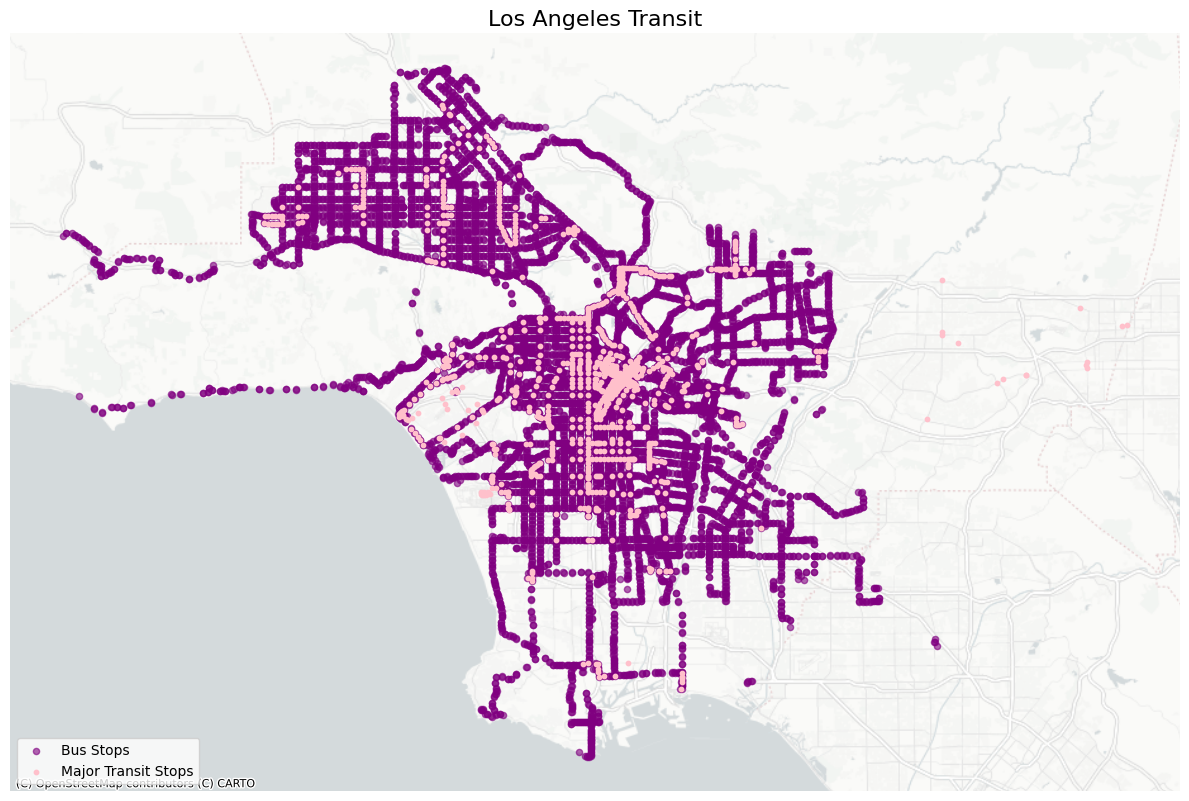

In [ ]:
# Visualize bus stops for possible shade placements
# Make sure both layers use the same projection (Web Mercator for basemap)
bus_stops = bus_stops.to_crs(epsg=3857)
major_transit_stops = major_transit_stops.to_crs(epsg=3857)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 10))

# Plot all bus stops in light purple (lower zorder so they're underneath)
bus_stops.plot(ax=ax, color='purple', markersize=20, alpha=0.6, label='Bus Stops', zorder=1)

# Plot major transit stops (la county) in orange (on top)
major_transit_stops.plot(ax=ax, color='pink', markersize=10,
                         label='Major Transit Stops', zorder=2)

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels)

# Style tweaks
ax.set_axis_off()
ax.set_title('Los Angeles Transit', fontsize=16)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

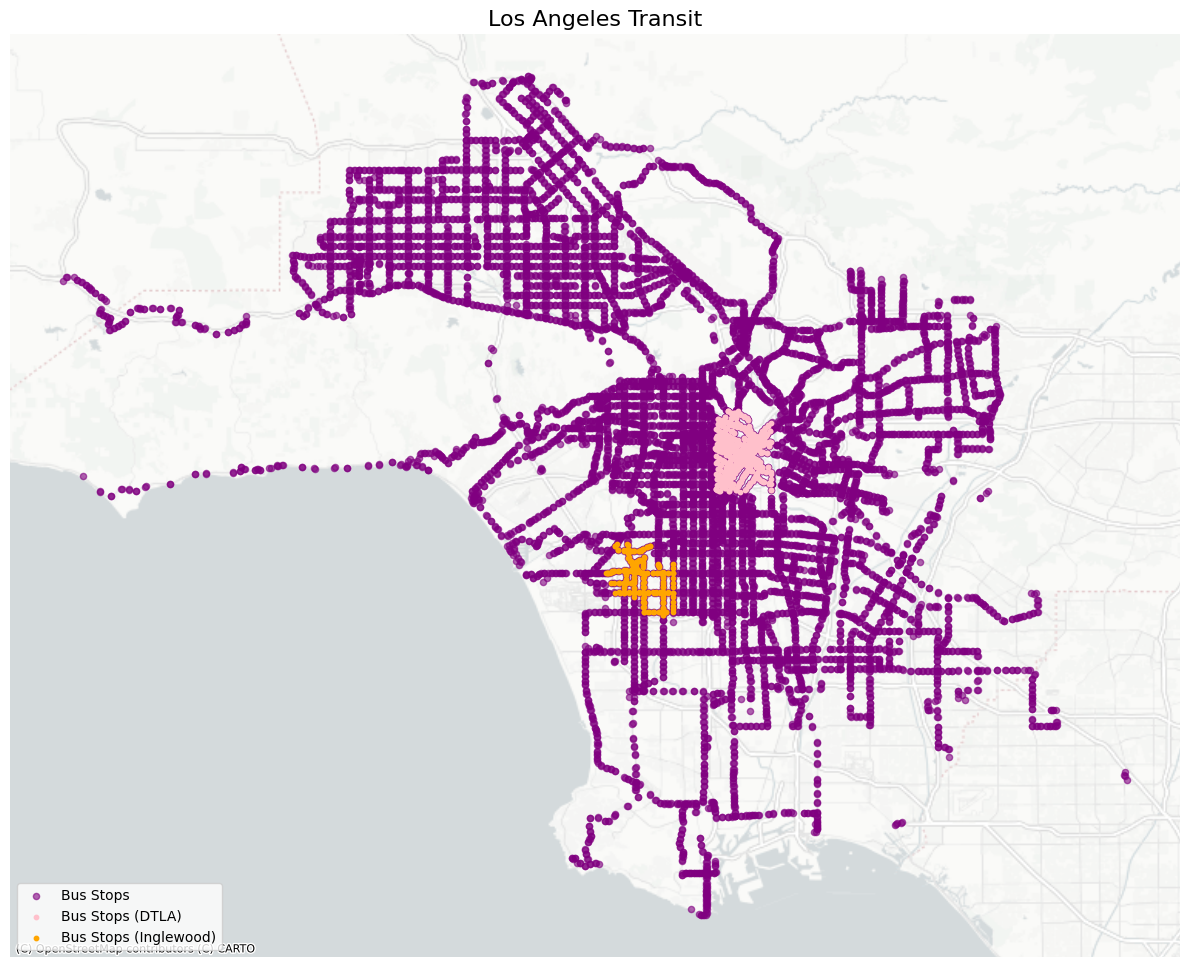

In [ ]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 10))

# Plot all bus stops in light purple (lower zorder so they're underneath)
bus_stops.plot(ax=ax, color='purple', markersize=20, alpha=0.6, label='Bus Stops', zorder=1)

# Plot bus stops in dtla in orange (on top)
bus_stops_dtla.plot(ax=ax, color='orange', markersize=10,
                         label='Bus Stops (DTLA)', zorder=2)

# Plot bus stops in inglewood in orange (on top)
bus_stops_inglewood.plot(ax=ax, color='green', markersize=10,
                         label='Bus Stops (Inglewood)', zorder=3)

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels)

# Style tweaks
ax.set_axis_off()
ax.set_title('Los Angeles Transit', fontsize=16)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

Food, School, Hospital Public Service Graphs

/var/folders/wl/c3pz93w50hz8v01l8clvl_qc0000gn/T/ipykernel_81646/4286413885.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  hospitals_dtla.plot(ax=ax, color='red', markersize=20, marker='D', label='Hospitals (DTLA)', zorder=4)
/var/folders/wl/c3pz93w50hz8v01l8clvl_qc0000gn/T/ipykernel_81646/4286413885.py:44: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  hospitals_inglewood.plot(ax=ax, color='red', markersize=20, marker='D', label='Hospitals', zorder=4)


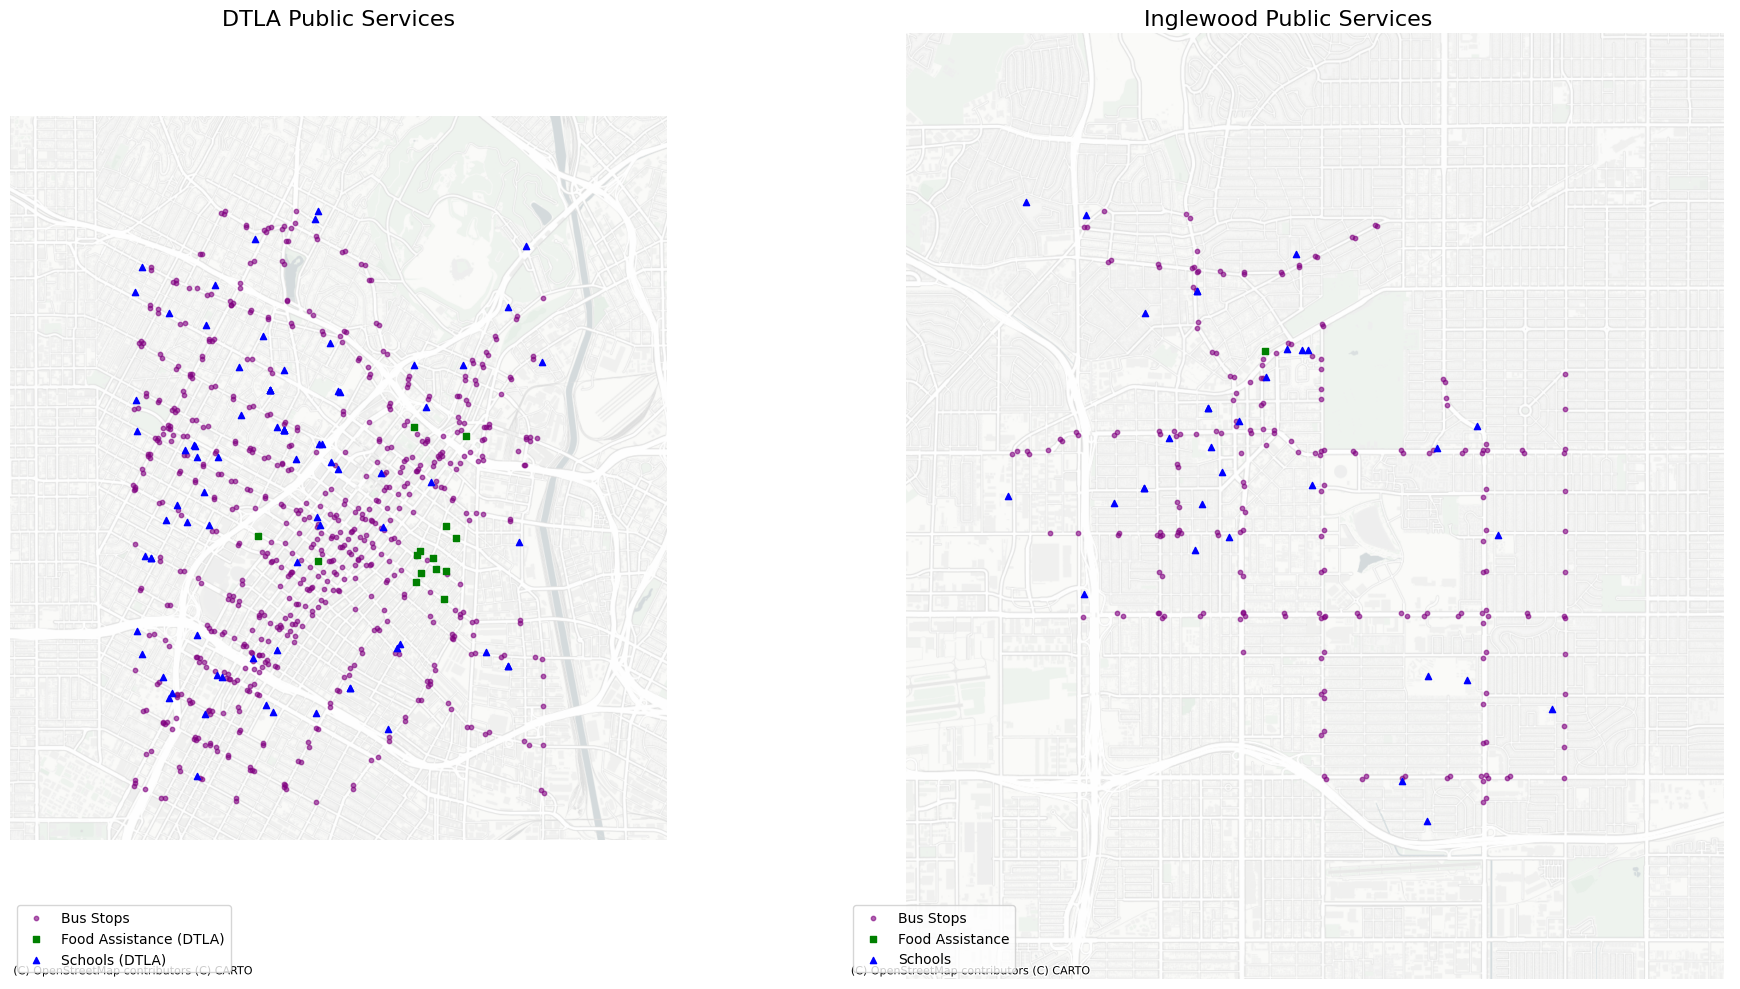

In [ ]:
import matplotlib.pyplot as plt
import contextily as cx

# Make sure all layers use the same projection (Web Mercator)
layers = [food_dtla, schools_dtla, hospitals_dtla, bus_stops]
for gdf in layers:
    gdf.to_crs(epsg=3857, inplace=True)

# Also project Inglewood layers
food_inglewood = food_inglewood.to_crs(epsg=3857)
schools_inglewood = schools_inglewood.to_crs(epsg=3857)
hospitals_inglewood = hospitals_inglewood.to_crs(epsg=3857)
bus_stops_inglewood = bus_stops_inglewood.to_crs(epsg=3857)

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# -------------------- DTLA --------------------
ax = axes[0]
bus_stops_dtla.plot(ax=ax, color='purple', markersize=10, alpha=0.6, label='Bus Stops', zorder=1)
food_dtla.plot(ax=ax, color='green', markersize=20, marker='s', label='Food Assistance (DTLA)', zorder=4)
schools_dtla.plot(ax=ax, color='blue', markersize=20, marker='^', label='Schools (DTLA)', zorder=4)
hospitals_dtla.plot(ax=ax, color='red', markersize=20, marker='D', label='Hospitals (DTLA)', zorder=4)

cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels)

# Zoom to DTLA area
minx, miny, maxx, maxy = bus_stops_dtla.total_bounds
padding_val = 0.3
x_pad = (maxx - minx) * padding_val
y_pad = (maxy - miny) * padding_val
ax.set_xlim(minx - x_pad, maxx + x_pad)
ax.set_ylim(miny - y_pad, maxy + y_pad)

ax.set_axis_off()
ax.set_title("DTLA Public Services", fontsize=16)
ax.legend(loc='lower left')

# -------------------- Inglewood --------------------
ax = axes[1]
bus_stops_inglewood.plot(ax=ax, color='purple', markersize=10, alpha=0.6, label='Bus Stops', zorder=1)
food_inglewood.plot(ax=ax, color='green', markersize=20, marker='s', label='Food Assistance', zorder=4)
schools_inglewood.plot(ax=ax, color='blue', markersize=20, marker='^', label='Schools', zorder=4)
hospitals_inglewood.plot(ax=ax, color='red', markersize=20, marker='D', label='Hospitals', zorder=4)

cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels)

# Zoom to Inglewood area
minx, miny, maxx, maxy = bus_stops_inglewood.total_bounds
x_pad = (maxx - minx) * padding_val
y_pad = (maxy - miny) * padding_val
ax.set_xlim(minx - x_pad, maxx + x_pad)
ax.set_ylim(miny - y_pad, maxy + y_pad)

ax.set_axis_off()
ax.set_title("Inglewood Public Services", fontsize=16)
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()


Heat + Socioeconomic Layer Visualizations on DTLA and Inglewood

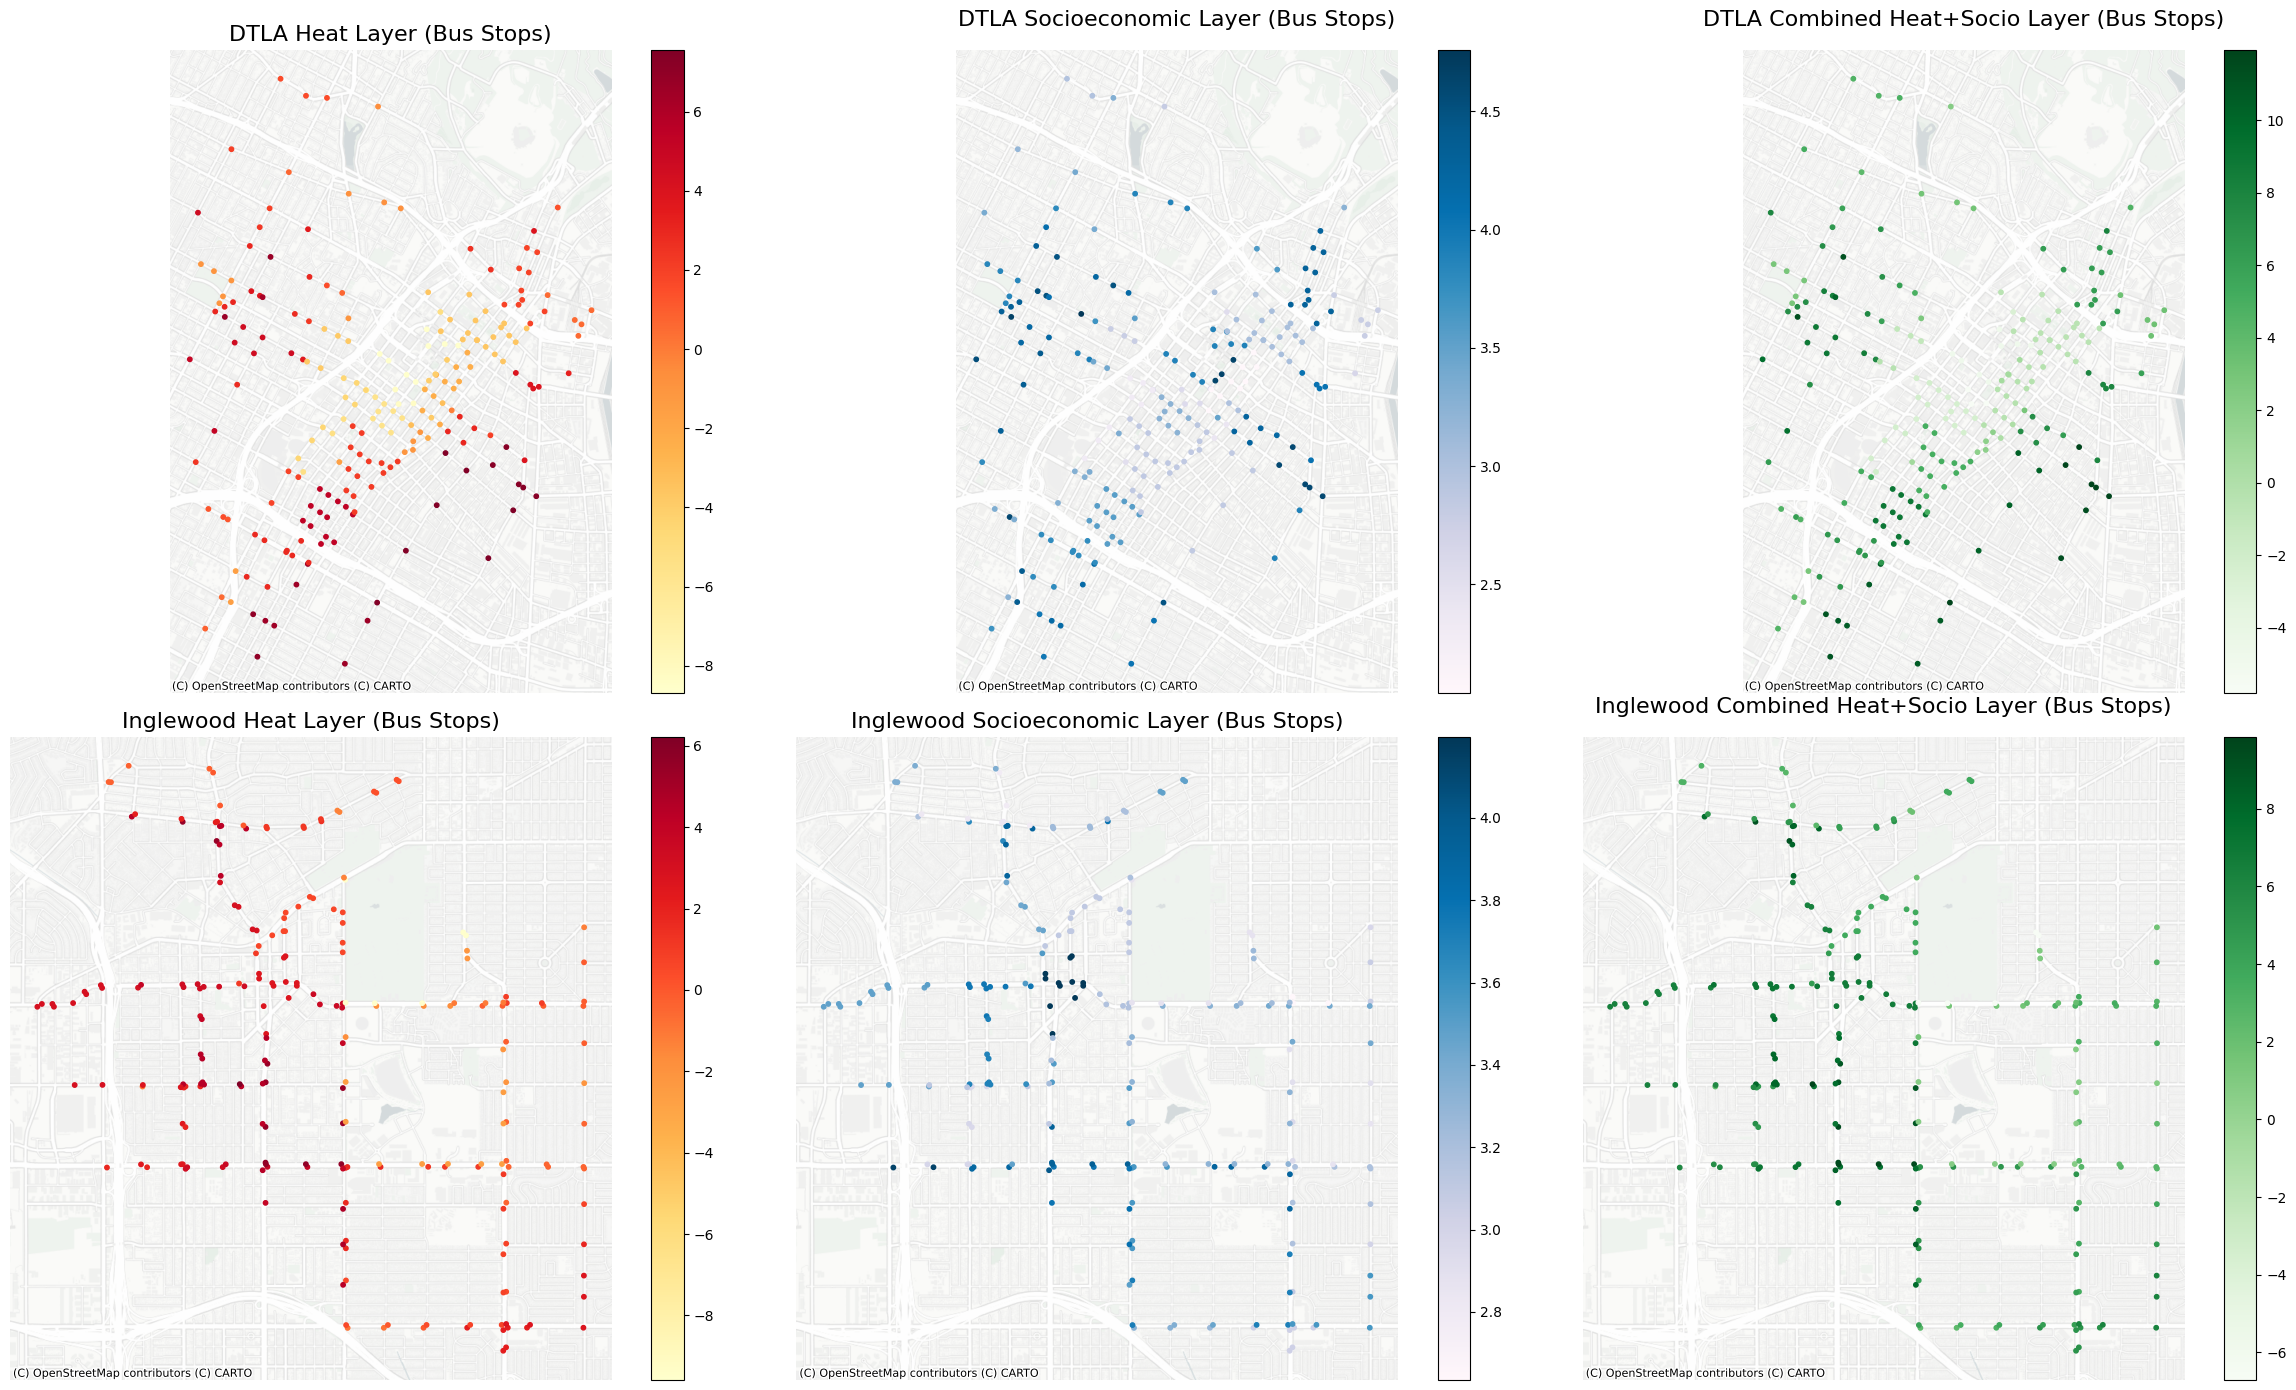

In [ ]:
# Set CRS
crs_target="EPSG:3857"

import matplotlib.pyplot as plt
import contextily as cx
import geopandas as gpd

# -------------------- Ensure projections match --------------------
crs_target = "EPSG:3857"

# Reproject bus stops with processed layers
processed_shade_stops_dtla = processed_shade_stops_dtla.to_crs(crs_target)
processed_shade_stops_inglewood = processed_shade_stops_inglewood.to_crs(crs_target)

# -------------------- Plotting --------------------
fig, axes = plt.subplots(2, 3, figsize=(24, 14))  # 2 rows, 3 columns
axes = axes.flatten()

# -------------------- DTLA --------------------
# Heat layer
processed_shade_stops_dtla.plot(
    ax=axes[0], column='heat_layer', cmap='YlOrRd', markersize=10, legend=True
)
cx.add_basemap(axes[0], source=cx.providers.CartoDB.PositronNoLabels, crs=crs_target)
axes[0].set_title("DTLA Heat Layer (Bus Stops)", fontsize=16)
axes[0].set_axis_off()

# Socioeconomic layer
processed_shade_stops_dtla.plot(
    ax=axes[1], column='socioeconomic_layer', cmap='PuBu', markersize=10, legend=True
)
cx.add_basemap(axes[1], source=cx.providers.CartoDB.PositronNoLabels, crs=crs_target)
axes[1].set_title("DTLA Socioeconomic Layer (Bus Stops)", fontsize=16)
axes[1].set_axis_off()

# Combined heat + socio
processed_shade_stops_dtla.plot(
    ax=axes[2], column='heat_socio_layer', cmap='Greens', markersize=10, legend=True
)
cx.add_basemap(axes[2], source=cx.providers.CartoDB.PositronNoLabels, crs=crs_target)
axes[2].set_title("DTLA Combined Heat+Socio Layer (Bus Stops)", fontsize=16)
axes[2].set_axis_off()

# -------------------- Inglewood --------------------
# Heat layer
processed_shade_stops_inglewood.plot(
    ax=axes[3], column='heat_layer', cmap='YlOrRd', markersize=10, legend=True
)
cx.add_basemap(axes[3], source=cx.providers.CartoDB.PositronNoLabels, crs=crs_target)
axes[3].set_title("Inglewood Heat Layer (Bus Stops)", fontsize=16)
axes[3].set_axis_off()

# Socioeconomic layer
processed_shade_stops_inglewood.plot(
    ax=axes[4], column='socioeconomic_layer', cmap='PuBu', markersize=10, legend=True
)
cx.add_basemap(axes[4], source=cx.providers.CartoDB.PositronNoLabels, crs=crs_target)
axes[4].set_title("Inglewood Socioeconomic Layer (Bus Stops)", fontsize=16)
axes[4].set_axis_off()

# Combined heat + socio
processed_shade_stops_inglewood.plot(
    ax=axes[5], column='heat_socio_layer', cmap='Greens', markersize=10, legend=True
)
cx.add_basemap(axes[5], source=cx.providers.CartoDB.PositronNoLabels, crs=crs_target)
axes[5].set_title("Inglewood Combined Heat+Socio Layer (Bus Stops)", fontsize=16)
axes[5].set_axis_off()

plt.tight_layout()
plt.show()


Run MILP Optimizer on DTLA

n:  222  p:  94
dist_stats:  Candidate distances stats (upper tri) — min: 2.47 m, max: 7831.23 m, mean: 2477.40 m, median: 2372.62 m
 
public_stats:  Public distances stats — min: 32.40 m, max: 8537.86 m, mean: 2785.50 m, median: 2655.74 m

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/urvibhuwania/miniconda3/lib/python3.13/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/wl/c3pz93w50hz8v01l8clvl_qc0000gn/T/b5667cb404d24a14a9919d50f41b9ac8-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/wl/c3pz93w50hz8v01l8clvl_qc0000gn/T/b5667cb404d24a14a9919d50f41b9ac8-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 73599 COLUMNS
At line 295267 RHS
At line 368862 BOUNDS
At line 393616 ENDATA
Problem MODEL has 73594 rows, 24753 columns and 171939 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value i

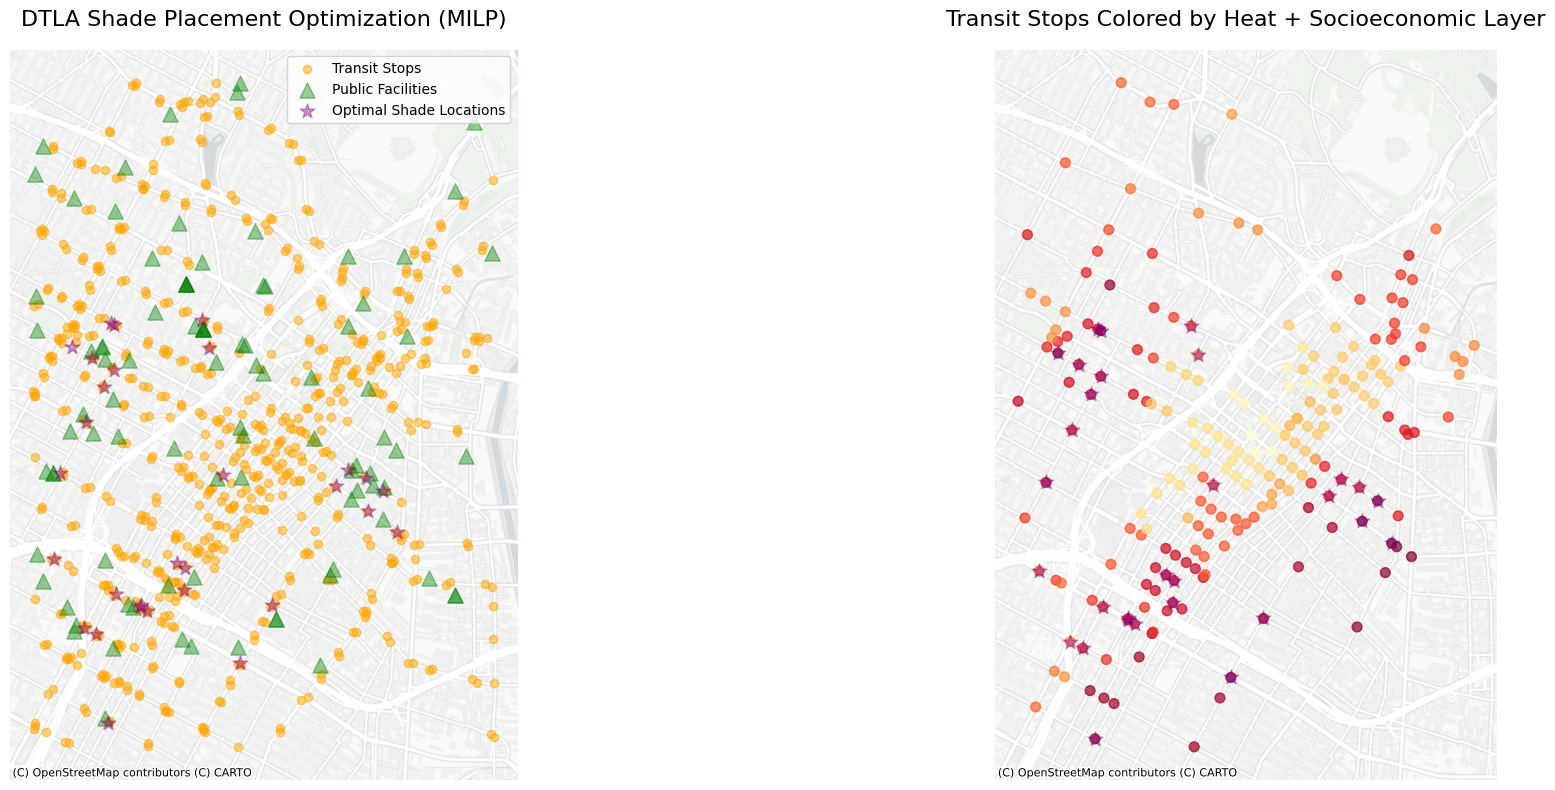

In [ ]:
# --- Run the MILP optimizer ---
optimized_shades = optimize_shade_placement(
    candidate_points=processed_shade_stops_dtla,
    public_points=public_points_dtla,
    max_shades=30,
    use_spacing=True,
    use_public=True,
    use_heat=True,
    use_socioeconomic=True,
    spacing_threshold=500,
    public_service_threshold=300,
)

print(f"Selected {len(optimized_shades)} optimal shade sites.")

# --- Visualize ---
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# Plot the first graph visualizing optimal shade locations against proximity to public service buildings
bus_stops_dtla.plot(ax=axes[0], color='orange', label='Transit Stops', alpha=0.5)
public_points_dtla.plot(ax=axes[0], color='green', marker='^', label='Public Facilities', alpha=0.4, markersize=100)
optimized_shades.plot(ax=axes[0], color='purple', marker='*', markersize=120, alpha = 0.4, label='Optimal Shade Locations')

cx.add_basemap(axes[0], source=cx.providers.CartoDB.PositronNoLabels)
axes[0].legend()
axes[0].set_title("DTLA Shade Placement Optimization (MILP)", fontsize=16)
axes[0].set_axis_off()

# Plot the second graph visualizing heat and socioeconomic priority layers
processed_shade_stops_dtla.plot(
    ax=axes[1],
    cmap = 'YlOrRd',
    column="heat_socio_layer",
    markersize=50,
    alpha=0.7
)
optimized_shades.plot(ax=axes[1], color='purple', marker='*', markersize=120, alpha=0.4, label='Optimal Shade Locations')
cx.add_basemap(axes[1], source=cx.providers.CartoDB.PositronNoLabels)
axes[1].set_title("Transit Stops Colored by Heat + Socioeconomic Layer", fontsize=16)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

Run MILP on Inglewood

n:  224  p:  34
dist_stats:  Candidate distances stats (upper tri) — min: 18.24 m, max: 8751.32 m, mean: 3118.03 m, median: 2973.48 m
 
public_stats:  Public distances stats — min: 13.66 m, max: 9443.59 m, mean: 3094.66 m, median: 2931.73 m

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/urvibhuwania/miniconda3/lib/python3.13/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/wl/c3pz93w50hz8v01l8clvl_qc0000gn/T/e869eb40b2b84ecb9e2b3f96fc1d2675-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/wl/c3pz93w50hz8v01l8clvl_qc0000gn/T/e869eb40b2b84ecb9e2b3f96fc1d2675-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 74934 COLUMNS
At line 300615 RHS
At line 375545 BOUNDS
At line 400746 ENDATA
Problem MODEL has 74929 rows, 25200 columns and 175056 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value 

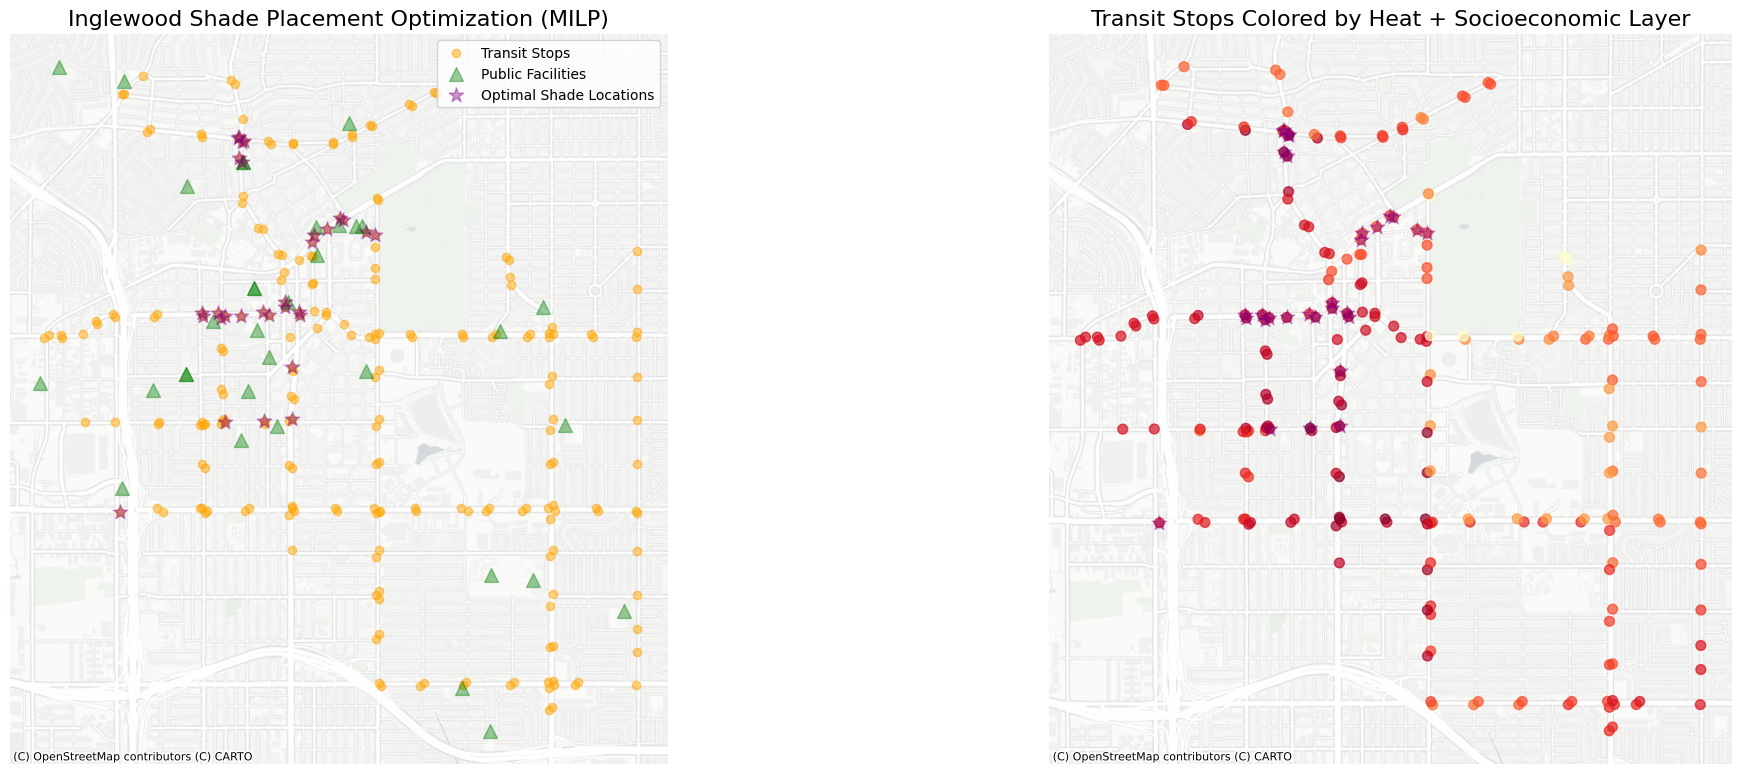

In [ ]:
# --- Run the MILP optimizer ---
optimized_shades = optimize_shade_placement(
    candidate_points=processed_shade_stops_inglewood,
    public_points=public_points_inglewood,
    max_shades=30,
    use_spacing=True,
    use_public=True,
    use_heat=True,
    use_socioeconomic=True,
    spacing_threshold=500,
    public_service_threshold=300,
)

print(f"Selected {len(optimized_shades)} optimal shade sites.")

# --- Visualize ---
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# Plot the first graph visualizing optimal shade locations against proximity to public service buildings
bus_stops_inglewood.plot(ax=axes[0], color='orange', label='Transit Stops', alpha=0.5)
public_points_inglewood.plot(ax=axes[0], color='green', marker='^', label='Public Facilities', alpha=0.4, markersize=100)
optimized_shades.plot(ax=axes[0], color='purple', marker='*', markersize=120, alpha = 0.4, label='Optimal Shade Locations')

cx.add_basemap(axes[0], source=cx.providers.CartoDB.PositronNoLabels)
axes[0].legend()
axes[0].set_title("Inglewood Shade Placement Optimization (MILP)", fontsize=16)
axes[0].set_axis_off()

# Plot the second graph visualizing heat and socioeconomic priority layers
processed_shade_stops_inglewood.plot(
    ax=axes[1],
    cmap = 'YlOrRd',
    column="heat_socio_layer",
    markersize=50,
    alpha=0.7
)
optimized_shades.plot(ax=axes[1], color='purple', marker='*', markersize=120, alpha=0.4, label='Optimal Shade Locations')
cx.add_basemap(axes[1], source=cx.providers.CartoDB.PositronNoLabels)
axes[1].set_title("Transit Stops Colored by Heat + Socioeconomic Layer", fontsize=16)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()